**Table of contents**<a id='toc0_'></a>    
- [출처](#toc1_)    
- [제1유형_데이터 다루기](#toc2_)    
  - [데이터 불러오기](#toc2_1_)    
  - [유형1 - 데이터 타입(object, int, float, bool 등등)](#toc2_2_)    
  - [유형2 - 기초통계량(평균, 중앙값, 사분위수, IQR, 표준편차)](#toc2_3_)    
    - [1) 중심측도를 나타내는 값(평균, 중앙값, 최빈값)](#toc2_3_1_)    
    - [2) 산포도를 나타내는 값(분산, 표준편차, IQR, range(최대 - 최소) 등)](#toc2_3_2_)    
    - [3) 분포의 비대칭도](#toc2_3_3_)    
    - [4) 기타(합계, 절대값, 데이터 수 등)](#toc2_3_4_)    
    - [5) 그룹화하여 계산하기 (groupby 활용)](#toc2_3_5_)    
  - [유형3 - 데이터 인덱싱, 필터링, 정렬, 변경 등](#toc2_4_)    
    - [1) 데이터 인덱싱(loc, iloc) ※loc 인덱스 주의](#toc2_4_1_)    
    - [2) 열 추가/제거](#toc2_4_2_)    
    - [3) 데이터 필터링](#toc2_4_3_)    
    - [4) 데이터 정렬](#toc2_4_4_)    
    - [5) 데이터 변경(조건문), np.where](#toc2_4_5_)    
  - [유형4 - 결측치, 이상치, 중복값 처리(제거 or 대체)](#toc2_5_)    
    - [1) 결측치 확인 및 처리](#toc2_5_1_)    
      - [결측치 제거](#toc2_5_1_1_)    
      - [결측치 대체](#toc2_5_1_2_)    
    - [2) 이상치 확인 및 처리](#toc2_5_2_)    
      - [boxplot (1.5 * IQR)](#toc2_5_2_1_)    
      - [표준정규분포 (보통 3 * z)](#toc2_5_2_2_)    
    - [3) 중복값 제거](#toc2_5_3_)    
  - [유형5 - 데이터 스케일링(데이터 표준화, 데이터 정규화)](#toc2_6_)    
    - [1) 데이터 표준화(z-score normalization)](#toc2_6_1_)    
    - [2) 데이터 정규화(min-max normalization))](#toc2_6_2_)    
  - [유형6 - 데이터 합치기](#toc2_7_)    
  - [유형7 - 날짜/시간 데이터, index 다루기](#toc2_8_)    
    - [1) 날짜 다루기](#toc2_8_1_)    
      - [날짜가 인덱스인 경우](#toc2_8_1_1_)    
    - [2) 시간 다루기](#toc2_8_2_)    
- [시간 데이터 만들기](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[출처](#toc0_)
https://youtu.be/XTsTbqjJhjE?si=SuBUDiK0FK2XHthz

영상의 예제문제 따라하기

# <a id='toc2_'></a>[제1유형_데이터 다루기](#toc0_)

## <a id='toc2_1_'></a>[데이터 불러오기](#toc0_)

In [2]:
import pandas as pd
import numpy as np

In [3]:
mtcars_path = r'dataset\mtcars.csv'
df = pd.read_csv(mtcars_path)

df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## <a id='toc2_2_'></a>[유형1 - 데이터 타입(object, int, float, bool 등등)](#toc0_)

In [4]:
# 칼럼별 타입 확인

df.dtypes

model     object
mpg      float64
cyl        int64
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object

In [5]:
# 데이터 타입 변경(1개)

df1 = df.copy()
df1 = df1.astype({'cyl':'object'})

print(df1.dtypes)

model     object
mpg      float64
cyl       object
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object


In [6]:
# 데이터 타입 변경(2개)

df1 = df1.astype({'cyl':'int', 'gear':'object'})

print(df1.dtypes)

model     object
mpg      float64
cyl        int32
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear      object
carb       int64
dtype: object


In [7]:
df1['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

## <a id='toc2_3_'></a>[유형2 - 기초통계량(평균, 중앙값, 사분위수, IQR, 표준편차)](#toc0_)

### <a id='toc2_3_1_'></a>[1) 중심측도를 나타내는 값(평균, 중앙값, 최빈값)](#toc0_)

In [8]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [9]:
df.shape # (행, 열)

(32, 12)

In [10]:
mpg_mean = df['mpg'].mean()         # 평균
mpg_median = df['mpg'].median()     # 중앙값
cyl_mode = df['cyl'].mode()         # 최빈값

print('평균값', mpg_mean)
print('중앙값', mpg_median)
print('-'*20)
print('최빈값', cyl_mode)
print('-'*20)
print('최빈값', cyl_mode[0])

평균값 20.090625000000003
중앙값 19.2
--------------------
최빈값 0    8
Name: cyl, dtype: int64
--------------------
최빈값 8


In [11]:
# 최빈값 체크

df['cyl'].value_counts()

cyl
8    14
4    11
6     7
Name: count, dtype: int64

### <a id='toc2_3_2_'></a>[2) 산포도를 나타내는 값(분산, 표준편차, IQR, range(최대 - 최소) 등)](#toc0_)

In [12]:
# 분산

mpg_var = df['mpg'].var()

print(mpg_var)

36.32410282258065


In [13]:
# 표준편차

import math

mpg_std = df['mpg'].std()

print(mpg_std)
print(math.sqrt(mpg_var))

6.026948052089105
6.026948052089105


In [14]:
# IQR

Q1 = df['mpg'].quantile(.25)
Q3 = df['mpg'].quantile(.75)

IQR = Q3 - Q1

print(IQR)

7.375


In [15]:
# 범위

mpg_max = df['mpg'].max()
mpg_min = df['mpg'].min()

mpg_range = mpg_max - mpg_min

print(mpg_range)

23.5


### <a id='toc2_3_3_'></a>[3) 분포의 비대칭도](#toc0_)

In [16]:
# 왜도(Skewness): 분포의 비대칭 정도를 나타냄 (0이면 대칭, 음수면 왼쪽, 양수면 오른쪽으로 치우침)

mpg_skew = df['mpg'].skew()

print(mpg_skew)

0.6723771376290805


In [17]:
# 첨도(Kurtosis): 분포의 뾰족한 정도를 나타냄 (정규분포의 첨도는 3, 3보다 크면 뾰족, 작으면 평평)

mpg_kurt = df['mpg'].kurt()

print(mpg_kurt)

-0.0220062914240855


### <a id='toc2_3_4_'></a>[4) 기타(합계, 절대값, 데이터 수 등)](#toc0_)

In [18]:
# 합계

mpg_sum = df['mpg'].sum()

print(mpg_sum)

642.9000000000001


In [19]:
# 절대값

print(abs(1-3))

2


In [20]:
# 데이터 수

len(df['mpg'])

32

### <a id='toc2_3_5_'></a>[5) 그룹화하여 계산하기 (groupby 활용)](#toc0_)

In [21]:
# species별로 각 변수의 평균 구해보기

import seaborn as sns

iris = sns.load_dataset('iris')
display(iris)
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [22]:
iris.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


## <a id='toc2_4_'></a>[유형3 - 데이터 인덱싱, 필터링, 정렬, 변경 등](#toc0_)

In [23]:
df.head(7)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4


### <a id='toc2_4_1_'></a>[1) 데이터 인덱싱(loc, iloc) ※loc 인덱스 주의](#toc0_)

In [24]:
# 행,열 인덱싱

df.loc[3,'mpg']

21.4

In [25]:
# 열만 인덱싱

df.loc[:, 'mpg'].head()

0    21.0
1    21.0
2    22.8
3    21.4
4    18.7
Name: mpg, dtype: float64

In [26]:
# 다중 인덱싱

df.loc[0:3, ['mpg', 'cyl', 'disp']]     # ※ loc 인덱스는 뒤 숫자까지 포함! (0:3 == 0,1,2,3)ㅠ

,mpg,cyl,disp
0,21.0,6,160.0
1,21.0,6,160.0
2,22.8,4,108.0
3,21.4,6,258.0


In [27]:
# 다중 인덱싱 2

df.loc[0:3, 'mpg' : 'disp']

,mpg,cyl,disp
0,21.0,6,160.0
1,21.0,6,160.0
2,22.8,4,108.0
3,21.4,6,258.0


In [28]:
# 앞 / 뒤에서 n행 인덱싱

print('head')
display(df.head(3))
print('tail')
display(df.tail(4))

head


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1


tail


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
28,Ford Pantera L,15.8,8,351.0,264,4.22,3.17,14.5,0,1,5,4
29,Ferrari Dino,19.7,6,145.0,175,3.62,2.77,15.5,0,1,5,6
30,Maserati Bora,15.0,8,301.0,335,3.54,3.57,14.6,0,1,5,8
31,Volvo 142E,21.4,4,121.0,109,4.11,2.78,18.6,1,1,4,2


### <a id='toc2_4_2_'></a>[2) 열 추가/제거](#toc0_)

In [29]:
# 열 선택

df_cyl = df['cyl']

display(df_cyl.head(3))
display(df.cyl.head(3))
display(df['cyl'].head(3))
# 모두 같음음

0    6
1    6
2    4
Name: cyl, dtype: int64

0    6
1    6
2    4
Name: cyl, dtype: int64

0    6
1    6
2    4
Name: cyl, dtype: int64

In [30]:
# 여러 열 선택

df_new = df[['cyl', 'mpg']]
display(df_new.head(3))

,cyl,mpg
0,6,21.0
1,6,21.0
2,4,22.8


In [31]:
# 열 제거

df.drop(columns = ['model', 'mpg', 'cyl']).head(3)

,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,160.0,110,3.90,2.620,16.46,0,1,4,4
1,160.0,110,3.90,2.875,17.02,0,1,4,4
2,108.0,93,3.85,2.320,18.61,1,1,4,1


In [32]:
# 열 추가

df2= df.copy()
df2['new'] = df['mpg'] + 10
df2.head(3)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,new
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,31.0
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,31.0
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,32.8


### <a id='toc2_4_3_'></a>[3) 데이터 필터링](#toc0_)

In [33]:
# 1개 조건 필터링

cond1 = (df['cyl'] == 4)
len(df[cond1])  # 조건에 맞는 행의 개수

11

In [34]:
df[cond1]

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
20,Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2


In [35]:
# 2개 조건 필터링

cond2 = (df['mpg'] >= 22)

df[cond1 & cond2]  # and 조건

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2


In [36]:
df[cond1 | cond2]  # or 조건

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
20,Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
26,Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2


### <a id='toc2_4_4_'></a>[4) 데이터 정렬](#toc0_)

In [37]:
# 내림차순 정렬 (up to down)
df.sort_values('mpg', ascending = False).head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
19,Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
17,Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
18,Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
25,Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1


In [38]:
# 오름차순 정렬 (down to up)
df.sort_values('mpg', ascending = True).head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
15,Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4
14,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
23,Camaro Z28,13.3,8,350.0,245,3.73,3.840,15.41,0,0,3,4
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
16,Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4


### <a id='toc2_4_5_'></a>[5) 데이터 변경(조건문), np.where](#toc0_)

In [39]:
import numpy as np

# hp 변수 값 중에서 205가 넘는 값은 205로 처리하고, 나머지는 그대로 유지
df['hp'] = np.where(df['hp'] > 205, 205, df['hp'])

# 내림차순 정렬
df.sort_values('hp', ascending = False).head(10)

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
16,Chrysler Imperial,14.7,8,440.0,205,3.23,5.345,17.42,0,0,3,4
30,Maserati Bora,15.0,8,301.0,205,3.54,3.570,14.60,0,1,5,8
28,Ford Pantera L,15.8,8,351.0,205,4.22,3.170,14.50,0,1,5,4
6,Duster 360,14.3,8,360.0,205,3.21,3.570,15.84,0,0,3,4
23,Camaro Z28,13.3,8,350.0,205,3.73,3.840,15.41,0,0,3,4
15,Lincoln Continental,10.4,8,460.0,205,3.00,5.424,17.82,0,0,3,4
14,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
13,Merc 450SLC,15.2,8,275.8,180,3.07,3.780,18.00,0,0,3,3
11,Merc 450SE,16.4,8,275.8,180,3.07,4.070,17.40,0,0,3,3
12,Merc 450SL,17.3,8,275.8,180,3.07,3.730,17.60,0,0,3,3


## <a id='toc2_5_'></a>[유형4 - 결측치, 이상치, 중복값 처리(제거 or 대체)](#toc0_)

- 데이터 불러오기(타이타닉 데이터셋)
    *   종속변수(y): 생존여부(0 사망, 1 생존)
    *   독립변수(x): pclass, sex, age 등의 탑승자 정보(변수)

In [40]:
import seaborn as sns


# 데이터셋 목록: sns.get_dataset_names()
df = sns.load_dataset('titanic')

In [41]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [42]:
df.shape

(891, 15)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### <a id='toc2_5_1_'></a>[1) 결측치 확인 및 처리](#toc0_)

In [44]:
# 결측치 확인
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

#### <a id='toc2_5_1_1_'></a>[결측치 제거](#toc0_)

In [45]:
# 결측치 제거
print(df.dropna(axis = 0).shape)        # 행 기준
print(df.dropna(axis = 1).shape)        # 열 기준

(182, 15)
(891, 11)


#### <a id='toc2_5_1_2_'></a>[결측치 대체](#toc0_)

In [46]:
# 결측치 대체

# 데이터 복사
df2 = df.copy()
df2 = pd.DataFrame(df)

In [47]:
# 중앙값/평균값 등으로 대체

# 중앙값 구하기
median_age = df2['age'].median()
print('중앙값', median_age)

# # 평균값 구하기
# mea_age = df2['age'].mean()

중앙값 28.0


In [48]:
# 결측치 중앙값으로 대체
df2['age'] = df['age'].fillna(median_age)

In [49]:
# 대체 되었는지 확인
print(df2.isnull().sum())

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


### <a id='toc2_5_2_'></a>[2) 이상치 확인 및 처리](#toc0_)

#### <a id='toc2_5_2_1_'></a>[boxplot (1.5 * IQR)](#toc0_)

<Axes: >

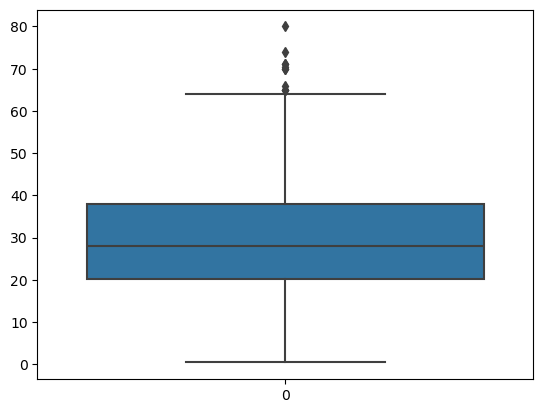

In [50]:
# boxplot 활용(이상치: Q1, Q3로부터 1.5*IQR 벗어난 값)
df = sns.load_dataset('titanic')

# (참고) boxplot 그리기, 실기 시험장에선 사용x
sns.boxplot(df['age'])

# 이상치가 나타나지 않는 경우는 해당 값이 min/max

In [51]:
# Q1, Q3, IQR 계산

Q1 = df['age'].quantile(.25)
Q3 = df['age'].quantile(.75)
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)   
print('IQR:', IQR)


Q1: 20.125
Q3: 38.0
IQR: 17.875


In [52]:
upper = Q3 + 1.5* IQR
lower = Q1 - 1.5* IQR

print('상한:', upper)
print('하한:', lower)

상한: 64.8125
하한: -6.6875


In [53]:
# 문제: age 변수의 이상치를 제외한 데이터의 수는?

cond1 = (df['age'] <= upper)
cond2 = (df['age'] >= lower)

print(len(df[cond1 & cond2]))

703


In [54]:
# 문제: age 변수의 이상치를 제외한 데이터셋 확인

df[cond1 & cond2]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#### <a id='toc2_5_2_2_'></a>[표준정규분포 (보통 3 * z)](#toc0_)

In [55]:
# Z = (X - μ) / σ

mean_age = df['age'].mean()
std_age = df['age'].std()

print('평균:', mean_age)
print('표준편차:', std_age)

평균: 29.69911764705882
표준편차: 14.526497332334044


In [56]:
znorm = (df['age'] - mean_age) / std_age
znorm

0     -0.530005
1      0.571430
2     -0.254646
3      0.364911
4      0.364911
         ...   
886   -0.185807
887   -0.736524
888         NaN
889   -0.254646
890    0.158392
Name: age, Length: 891, dtype: float64

In [57]:
cond1 = (znorm > 3)
cond2 = (znorm < -3)

len(znorm[cond1 | cond2])

2

### <a id='toc2_5_3_'></a>[3) 중복값 제거](#toc0_)

In [58]:
print(df.shape)

# copy
df1 = df.copy()

df1 = df1.drop_duplicates()
print(df1.shape)  # 중복 제거 후 데이터프레임의 크기 확인

# 중복값이 나오는 게 맞다면 제거x

(891, 15)
(784, 15)


## <a id='toc2_6_'></a>[유형5 - 데이터 스케일링(데이터 표준화, 데이터 정규화)](#toc0_)

### <a id='toc2_6_1_'></a>[1) 데이터 표준화(z-score normalization)](#toc0_)

In [59]:
df = pd.read_csv("dataset/mtcars.csv")
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [60]:
from sklearn.preprocessing import StandardScaler
zscaler = StandardScaler()

df['zscore'] = zscaler.fit_transform(df[['mpg']])       # 대괄호 2개인 이유: fit_transform() 함수는 2차원 배열을 입력으로 받기 때문에 데이터프레임 형태로 넣어야 함
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,zscore
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,0.153299
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,0.153299
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,0.456737
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,0.220730
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,-0.234427


In [61]:
# 셀프 계산으로 체크

mean_mpg = df['mpg'].mean()
std_mpg = df['mpg'].std()


df['zscore_self'] = (df['mpg'] - mean_mpg) / std_mpg
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,zscore,zscore_self
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,0.153299,0.150885
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,0.153299,0.150885
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,0.456737,0.449543
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,0.220730,0.217253
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,-0.234427,-0.230735


In [62]:
# 값이 다른 이유: 자유도 차이

np_std = np.std(df['mpg'], ddof=0)  # 표본이 아닌 모집단으로 계산, 기본값 ddof=0 -> 분모의 자유도는 N

np_std_self = np.std(df['mpg'], ddof=1)  # 표본으로 계산, ddof=1 -> 분모의 자유도는 N-1
df_std = df['mpg'].std()  # pandas의 std() 함수는 기본적으로 ddof=1로 표본으로 계산

print('numpy std(모표준편차):', np_std)
print('numpy std(표본표준편차1):', np_std_self)
print('pandas std(표본표준편차2):', df_std)

# 1유형에서는 웬만하면 직접 계산하는 게 좋음


numpy std(모표준편차): 5.932029552301219
numpy std(표본표준편차1): 6.026948052089105
pandas std(표본표준편차2): 6.026948052089105


### <a id='toc2_6_2_'></a>[2) 데이터 정규화(min-max normalization))](#toc0_)

In [63]:
df = pd.read_csv("dataset/mtcars.csv")
df.head()

from sklearn.preprocessing import MinMaxScaler
mscaler = MinMaxScaler()
df['mpg'] = mscaler.fit_transform(df[['mpg']])
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,0.451064,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,0.451064,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,0.527660,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,0.468085,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,0.353191,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## <a id='toc2_7_'></a>[유형6 - 데이터 합치기](#toc0_)

In [64]:
# 행, 열 방향으로 데이터 합치기
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [65]:
# 데이터 2개로 분리
df1 = df.loc[1:30, ]
df2 = df.loc[31:60, ]

df1.head()

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa


In [66]:
df2.head()

,sepal_length,sepal_width,petal_length,petal_width,species
31,5.4,3.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
34,4.9,3.1,1.5,0.2,setosa
35,5.0,3.2,1.2,0.2,setosa


In [67]:
df_sum = pd.concat([df1, df2], axis = 0) # axis=0: 행 방향으로 합치기
display(df_sum.head())
print(df_sum.shape)  # (61, 5)

,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa


(60, 5)


In [68]:
df_sum2 = pd.concat([df1, df2], axis = 1) # axis=1: 열 방향으로 합치기
display(df_sum2)
print(df_sum2.shape)  # (61, 5)

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_length,sepal_width,petal_length,petal_width,species
1,4.9,3.0,1.4,0.2,setosa,NaN,NaN,NaN,NaN,NaN
2,4.7,3.2,1.3,0.2,setosa,NaN,NaN,NaN,NaN,NaN
3,4.6,3.1,1.5,0.2,setosa,NaN,NaN,NaN,NaN,NaN
4,5.0,3.6,1.4,0.2,setosa,NaN,NaN,NaN,NaN,NaN
5,5.4,3.9,1.7,0.4,setosa,NaN,NaN,NaN,NaN,NaN
6,4.6,3.4,1.4,0.3,setosa,NaN,NaN,NaN,NaN,NaN
7,5.0,3.4,1.5,0.2,setosa,NaN,NaN,NaN,NaN,NaN
8,4.4,2.9,1.4,0.2,setosa,NaN,NaN,NaN,NaN,NaN
9,4.9,3.1,1.5,0.1,setosa,NaN,NaN,NaN,NaN,NaN
10,5.4,3.7,1.5,0.2,setosa,NaN,NaN,NaN,NaN,NaN


(60, 10)



## <a id='toc2_8_'></a>[유형7 - 날짜/시간 데이터, index 다루기](#toc0_)

### <a id='toc2_8_1_'></a>[1) 날짜 다루기](#toc0_)

In [69]:
# 데이터 다루기
df = pd.DataFrame({
    '날짜': ['20250123', '20250123', '20240125', '20250126',  '20250126'],
    '물품': ['A', 'B', 'A', 'A', 'B'],
    '판매수': [10, 20, 30, 40, 50],
    '개당수익': [1000, 2000, 3000, 4000, 5000]
})

df

,날짜,물품,판매수,개당수익
0,20250123,A,10,1000
1,20250123,B,20,2000
2,20240125,A,30,3000
3,20250126,A,40,4000
4,20250126,B,50,5000


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   날짜      5 non-null      object
 1   물품      5 non-null      object
 2   판매수     5 non-null      int64 
 3   개당수익    5 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 292.0+ bytes


In [71]:
# 데이터 타입 datetime으로 변경
df['날짜'] = pd.to_datetime(df['날짜'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      5 non-null      datetime64[ns]
 1   물품      5 non-null      object        
 2   판매수     5 non-null      int64         
 3   개당수익    5 non-null      int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 292.0+ bytes


In [72]:
# 년 월 일 변수 추가
df['년'] = df['날짜'].dt.year
df['월'] = df['날짜'].dt.month
df['일'] = df['날짜'].dt.day

df

,날짜,물품,판매수,개당수익,년,월,일
0,2025-01-23,A,10,1000,2025,1,23
1,2025-01-23,B,20,2000,2025,1,23
2,2024-01-25,A,30,3000,2024,1,25
3,2025-01-26,A,40,4000,2025,1,26
4,2025-01-26,B,50,5000,2025,1,26


In [73]:
# 날짜 구간 필터링
start_date = '2025-01-23'
end_date = '2025-01-26'

df[df['날짜'].between(start_date, end_date)] # 좌우 모두 포함

# 시간도 지정 가능
# ex) start_date = '2025-01-23 00:00:00'

,날짜,물품,판매수,개당수익,년,월,일
0,2025-01-23,A,10,1000,2025,1,23
1,2025-01-23,B,20,2000,2025,1,23
3,2025-01-26,A,40,4000,2025,1,26
4,2025-01-26,B,50,5000,2025,1,26


#### <a id='toc2_8_1_1_'></a>[날짜가 인덱스인 경우](#toc0_)

In [74]:
# 날짜가 인덱스인 경우

# 데이터 다시 만들기기
df = pd.DataFrame({
    '날짜': ['20250123', '20250123', '20240125', '20250126',  '20250126'],
    '물품': ['A', 'B', 'A', 'A', 'B'],
    '판매수': [10, 20, 30, 40, 50],
    '개당수익': [1000, 2000, 3000, 4000, 5000]
})

# 데이터 타입 datetime으로 변경 필수
df['날짜']= pd.to_datetime(df['날짜'])

df = df.set_index('날짜')  # 날짜를 인덱스로 설정, drop =True가 기본값
print(df)


           물품  판매수  개당수익
날짜                      
2025-01-23  A   10  1000
2025-01-23  B   20  2000
2024-01-25  A   30  3000
2025-01-26  A   40  4000
2025-01-26  B   50  5000


In [75]:
# 인덱스가 날짜인 경우, 날짜순으로 정렬
df = df.sort_index()

display(df.loc['2025-01-23':'2025-01-26'])  # 날짜 범위로 필터링, 좌우 모두 포함
display(df.loc[(df.index >= '2025-01-23') & (df.index <= '2025-01-26')])

,물품,판매수,개당수익
날짜,,,
2025-01-23,A,10,1000
2025-01-23,B,20,2000
2025-01-26,A,40,4000
2025-01-26,B,50,5000


,물품,판매수,개당수익
날짜,,,
2025-01-23,A,10,1000
2025-01-23,B,20,2000
2025-01-26,A,40,4000
2025-01-26,B,50,5000


### <a id='toc2_8_2_'></a>[2) 시간 다루기](#toc0_)

In [114]:
# 시간 데이터 만들기
df = pd.DataFrame({
    '물품': ['A', 'B', 'A', 'A', 'B'],
    '판매수': [10, 20, 30, 40, 50],
    '개당수익': [1000, 2000, 3000, 4000, 5000]
})

time = pd.date_range('2025-01-23 10:00:00', '2025-01-24 12:00:00' , periods=5)  # 5개 동일한 간격으로 생성
df['time'] = time

df = df[['time', '물품', '판매수', '개당수익']]  # 열 순서 변경
df

,time,물품,판매수,개당수익
0,2025-01-23 10:00:00,A,10,1000
1,2025-01-23 16:30:00,B,20,2000
2,2025-01-23 23:00:00,A,30,3000
3,2025-01-24 05:30:00,A,40,4000
4,2025-01-24 12:00:00,B,50,5000


In [115]:
# between 사용 가능

df[df['time'].between('2025-01-23 10:00:00', '2025-01-24 04:00:00')]  # 좌우 모두 포함

,time,물품,판매수,개당수익
0,2025-01-23 10:00:00,A,10,1000
1,2025-01-23 16:30:00,B,20,2000
2,2025-01-23 23:00:00,A,30,3000


#### 시간이 인덱스인 경우

In [116]:
# index 지정
df = df.set_index('time')  # time을 인덱스로 설정
df = df.sort_index()  # 인덱스 기준으로 정렬

df.between_time('04:00', '12:00')  # 시간 범위로 필터링, 좌우 모두 포함
# df = df.between_time('10:00', '12:00', include_start = False, include_end = False) -> # 좌우 모두 제외

,물품,판매수,개당수익
time,,,
2025-01-23 10:00:00,A,10,1000
2025-01-24 05:30:00,A,40,4000
2025-01-24 12:00:00,B,50,5000


In [117]:
# 참고) 인덱스 초기화
# df = df.reset_index()  # 인덱스를 초기화하고, 인덱스를 열로 변환
# df

In [118]:
# 2) loc 사용
# (주의) 시간이 index에 위치해야함

print(df.loc['2025-01-23 10:00:00':'2025-01-24 04:00:00'])  # 시간 범위로 필터링, 좌우 모두 포함
print(df.loc[(df.index >= '2025-01-23 10:00:00') & (df.index <= '2025-01-24 04:00:00')])  # 시간 범위로 필터링, 좌우 모두 포함

                    물품  판매수  개당수익
time                             
2025-01-23 10:00:00  A   10  1000
2025-01-23 16:30:00  B   20  2000
2025-01-23 23:00:00  A   30  3000
                    물품  판매수  개당수익
time                             
2025-01-23 10:00:00  A   10  1000
2025-01-23 16:30:00  B   20  2000
2025-01-23 23:00:00  A   30  3000
